# 从零实现 Transformer 编码器（文本分类）

- **作者**：邓涵丹
- **日期**：2026-07-27
- **适用周次**：Week 4
- **分类**：NLP / PyTorch
- **关键词**：Transformer、自注意力、多头注意力、位置编码、文本分类
- **适合读者**：了解注意力机制，熟悉 PyTorch 模块定义

## 学习目标

1. 手动实现 Scaled Dot-Product Attention 和多头注意力。
2. 实现位置编码和前馈网络，组装完整的 Transformer 编码器块。
3. 使用编码器进行文本分类，并与 BiLSTM 对比。

## 1. 背景与问题

Transformer 摒弃了 RNN 的递归结构，完全基于注意力机制，并行能力强，成为 NLP 的主流架构。本 Notebook 将逐步实现 Transformer 编码器，并应用于文本分类任务。

In [1]:
import os
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from tqdm import tqdm
import sys
import re
from collections import Counter
from datasets import load_dataset

print("PyTorch version:", torch.__version__)

PyTorch version: 1.13.0+cu117


## 2. 核心组件实现

### 2.1 缩放点积注意力
### 2.2 多头注意力
### 2.3 位置编码
### 2.4 前馈网络
### 2.5 Transformer 编码器块

In [2]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_k):
        super().__init__()
        self.d_k = d_k

    def forward(self, Q, K, V, mask=None):
        # Q, K, V: (B, h, L, d_k)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn = F.softmax(scores, dim=-1)
        return torch.matmul(attn, V), attn

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_head, d_k, d_v):
        super().__init__()
        self.n_head = n_head
        self.d_k = d_k
        self.d_v = d_v
        self.W_Q = nn.Linear(d_model, n_head * d_k, bias=False)
        self.W_K = nn.Linear(d_model, n_head * d_k, bias=False)
        self.W_V = nn.Linear(d_model, n_head * d_v, bias=False)
        self.fc = nn.Linear(n_head * d_v, d_model, bias=False)
        self.attention = ScaledDotProductAttention(d_k)

    def forward(self, x, mask=None):
        B, L, _ = x.size()
        Q = self.W_Q(x).view(B, L, self.n_head, self.d_k).transpose(1, 2)  # (B, h, L, d_k)
        K = self.W_K(x).view(B, L, self.n_head, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(B, L, self.n_head, self.d_v).transpose(1, 2)
        attn_out, _ = self.attention(Q, K, V, mask)
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, L, self.n_head * self.d_v)
        return self.fc(attn_out)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        return self.fc2(self.dropout(F.gelu(self.fc1(x))))

class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, n_head, d_k, d_v, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_head, d_k, d_v)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_output = self.self_attn(x, mask)
        x = self.norm1(x + self.dropout1(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout2(ff_output))
        return x

## 2.1 为什么 Attention 需要除以 √d_k？

公式为：Attention(Q,K,V) = softmax(Q·K^T / √d_k) · V

**为什么要除以 √d_k（Scale）？**
- 假设 Q 和 K 是独立的随机变量，且均值为 0，方差为 1（经过 LayerNorm 后通常如此）。
- Q 和 K 的点积（Q·K^T）的方差会随着维度 `d_k` 的增大而线性增加（变成 `d_k`）。
- 如果维度很大（比如 512），点积的数值会非常大，可能落到 Softmax 函数的**梯度饱和区**（即极端的 0 或 1）。
- 在饱和区，Softmax 的梯度极小，导致反向传播时参数更新极其缓慢，模型难以训练。

**缩放的作用**：
除以 `√d_k` 可以将点积的方差拉回 1，使得 Softmax 能够保持正常的梯度，让训练过程更加稳定。

## 2.2 为什么用正弦波（Sin/Cos）做位置编码？

Transformer 的 Self-Attention 本身是“置换不变”的（即打乱输入顺序，Attention 结果不变）。为了利用序列的顺序信息，必须显式加入位置编码。
选择 Sin/Cos 函数，主要有三大优势：

1. **相对位置表达能力**：
   数学上可以证明，对于任意固定的偏移量 `k`，位置 `pos+k` 的编码向量可以表示为位置 `pos` 编码向量的线性变换。这意味着模型能够轻松通过线性运算捕捉到“距离为 k”的两个词之间的相对位置关系。

2. **值域稳定**：
   正弦/余弦函数的值域固定在 [-1, 1] 之间，不会像可学习的位置编码那样产生过大的数值，有助于维持训练的稳定性。

3. **无需额外参数**：
   这种编码是确定性的，不引入额外的可训练参数，减少了过拟合风险，且能处理比训练集更长的序列（外推能力较好）。

## 3. 完整分类器模型

堆叠多个编码器块，然后使用全局平均池化+分类层。

In [3]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=128, n_head=4, d_k=32, d_v=32, d_ff=256,
                 num_layers=2, num_classes=2, max_len=512, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)  # pad_idx=0 # pad_idx=0
        self.positional_encoding = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(d_model, n_head, d_k, d_v, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.fc = nn.Linear(d_model, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        # input_ids: (B, L)
        x = self.dropout(self.embedding(input_ids))  # (B, L, d_model)
        x = self.positional_encoding(x)
        for layer in self.layers:
            x = layer(x)
        # 全局平均池化
        x = x.mean(dim=1)  # (B, d_model)
        return self.fc(x)

In [4]:
# ========== 自定义分词器 ==========
def simple_tokenizer(text):
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text.lower().split()

# ========== 加载 AG_NEWS 数据集 ==========
dataset = load_dataset("ag_news")
train_data = dataset["train"]
test_data = dataset["test"]
print(f"训练集大小: {len(train_data)}, 测试集大小: {len(test_data)}")

# ========== 构建词汇表 ==========
def build_vocab(data_iter, min_freq=2):
    counter = Counter()
    for sample in data_iter:
        tokens = simple_tokenizer(sample["text"])
        counter.update(tokens)
    vocab = {'<pad>': 0, '<unk>': 1}
    idx = 2
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1
    return vocab

vocab = build_vocab(train_data)
print(f"词汇表大小: {len(vocab)}")

# ========== 创建 PyTorch Dataset ==========
class AGNewsDataset(Dataset):
    def __init__(self, data, vocab, tokenizer, label_map=None):
        self.samples = []
        for item in data:
            text = item["text"]
            label = item["label"]
            if label_map is not None:
                label = label_map[label]
            tokens = [vocab.get(token, vocab['<unk>']) for token in tokenizer(text)]
            self.samples.append((torch.tensor(tokens, dtype=torch.long),
                                 torch.tensor(label, dtype=torch.long)))
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        return self.samples[idx]

# 标签映射：0,1 -> 0；2,3 -> 1 (二分类)
label_map = {0:0, 1:0, 2:1, 3:1}

train_dataset = AGNewsDataset(train_data, vocab, simple_tokenizer, label_map)
test_dataset = AGNewsDataset(test_data, vocab, simple_tokenizer, label_map)

# ========== collate 函数（仅填充，无需返回 lengths） ==========
def collate_batch(batch):
    texts, labels = zip(*batch)
    padded_texts = torch.nn.utils.rnn.pad_sequence(texts, batch_first=True, padding_value=vocab['<pad>'])
    labels = torch.tensor(labels, dtype=torch.long)
    return padded_texts, labels

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

训练集大小: 120000, 测试集大小: 7600
词汇表大小: 54864


## 4. 训练与评估

注意：Transformer 训练需要更多 epoch 或调整学习率。

In [5]:
vocab_size = len(vocab)
model = TransformerClassifier(vocab_size)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for texts, labels in tqdm(loader, desc="Training"):
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for texts, labels in tqdm(loader, desc="Evaluating"):
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

EPOCHS = 5
train_losses, train_accs, test_accs = [], [], []
for epoch in range(1, EPOCHS+1):
    loss, acc = train_epoch(model, train_loader, optimizer, criterion)
    test_acc = evaluate(model, test_loader)
    train_losses.append(loss)
    train_accs.append(acc)
    test_accs.append(test_acc)
    print(f"Epoch {epoch}: Train Loss={loss:.4f}, Train Acc={acc:.4f}, Test Acc={test_acc:.4f}")

Evaluating: 100%|██████████| 119/119 [00:00<00:00, 851.16it/s]


Epoch 1: Train Loss=0.2216, Train Acc=0.9092, Test Acc=0.9503


Evaluating: 100%|██████████| 119/119 [00:00<00:00, 962.76it/s]


Epoch 2: Train Loss=0.1315, Train Acc=0.9531, Test Acc=0.9571


Evaluating: 100%|██████████| 119/119 [00:00<00:00, 941.52it/s]


Epoch 3: Train Loss=0.1064, Train Acc=0.9626, Test Acc=0.9616


Evaluating: 100%|██████████| 119/119 [00:00<00:00, 954.22it/s]


Epoch 4: Train Loss=0.0906, Train Acc=0.9686, Test Acc=0.9612


Evaluating: 100%|██████████| 119/119 [00:00<00:00, 942.33it/s]

Epoch 5: Train Loss=0.0800, Train Acc=0.9723, Test Acc=0.9616


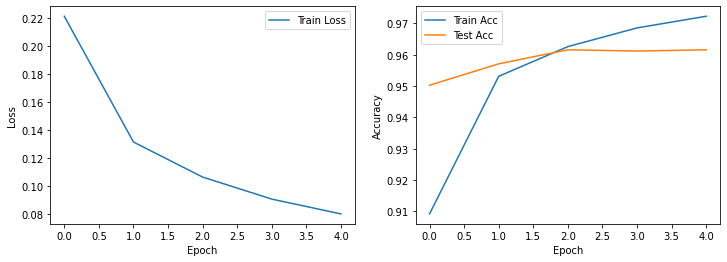

Transformer 模型已保存。


In [6]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(test_accs, label='Test Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

os.makedirs('./intermediate_data', exist_ok=True)
torch.save(model.state_dict(), './intermediate_data/transformer_classifier.pt')
print("Transformer 模型已保存。")